#**Weather Forecast Prediction Using Machine Learning🌦️**

This notebook builds and evaluates multiple machine learning models to predict rainfall based on meteorological features.

We perform:
1.  Dataset Exploration  
2.  Model Development and Training
3.  Hyperparameter Tuning
4.  Model Comparison
5.  Results and Evaluation

In [39]:
# Kaggle
!pip install kagglehub[pandas-datasets]

In [40]:
# Initial imports
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np

In [41]:
# Import Dataset from Kaggle
file_path = "weather_forecast_data.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "zeeshier/weather-forecast-dataset",
    file_path
)

Using Colab cache for faster access to the 'weather-forecast-dataset' dataset.


In [42]:
# Custom color palette
COLORS = {
    "rain": "#0B3C5D",        # deep blue
    "no_rain": "#F4A261",     # orangish yellow

    "logistic": "#A7C7E7",    # light blue
    "tree": "#0B3C5D",        # deep blue
    "knn": "#CDB4DB",         # lavender

    "baseline": "red"         # ROC diagonal
}

palette = {
    1: "#0A3D62",   # rain → deep blue
    0: "#F5A623"    # no rain → orange
}

## **1. Dataset Exploration**

As seen in the code cells below, the dataset has the following properties:


**Dataset Shape:** 2500 instances

**Dataset Features:**
*   Numerical (float64):
    *   Temperature: from 10ºC to almost 35ºC, average of 22.58 ºC
    *   Humidity: from 30ºC to almost 100ºC, average of 64.34ºC
    *   Wind Speed: from 0 to 20 km/h, average of 9.9 km/h
    *   Cloud Cover: from 0% to 100%, average of 49.66%
    *   Pressure: from 980 to 1050 hPa, average of 1014 hPa.
*   Categorical (object):
    *   Rain ("rain", "no rain")

  
**Dataset Missing Data:** There is no missing data

**Dataset Duplicates Handling:** There are no duplicates







In [43]:
# First elements of the dataset
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [44]:
# Dataset shape and features
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:")
df.info()

Shape: (2500, 6)

Columns:
 Index(['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure',
       'Rain'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


In [45]:
# Feature Analysis
df.describe()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,22.581725,64.347094,9.906255,49.658104,1014.312336
std,7.326996,19.954739,5.780316,29.123104,20.196433
min,10.001842,30.005071,0.009819,0.015038,980.014486
25%,16.359398,47.339815,4.761909,23.900016,996.938630
50%,22.536448,63.920797,9.908572,49.488284,1013.433035
75%,28.976476,81.561021,14.948408,75.324140,1031.735067
max,34.995214,99.997481,19.999132,99.997795,1049.985593


In [46]:
# Finding missing data
df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind_Speed,0
Cloud_Cover,0
Pressure,0
Rain,0


In [47]:
# Define target/output feature
target_column = df.columns[-1]   # commonly last column in Kaggle datasets

print("Target column:", target_column)

Target column: Rain


### **Further Feature Exploration**
#### **Data Cleaning**
Before model training, we clean the dataset by:
- Removing duplicate rows*
- Handling missing values*:
  - Numerical features → median imputation
  - Categorical features → mode imputation

\* *Despite the dataset not having duplicates or missing data, we report this for completeness*


#### **Feature Analysis**
Below, we report a series of graphs:
- **Pairwisre Relationship:** The pair plot highlights the relationships between the features and their potential influence on predicting Rain.
- **Feature Correlation:** shows how strongly features in the dataset are related to each other.
- **Feature Distribution:** In this case, the numerical features influencing the outcome of rain are balanced.
- **Class Distribution:** There exists a considerable class imbalance, with a higher number of no rain instances compared to rain, which needs to be considered moving forward.


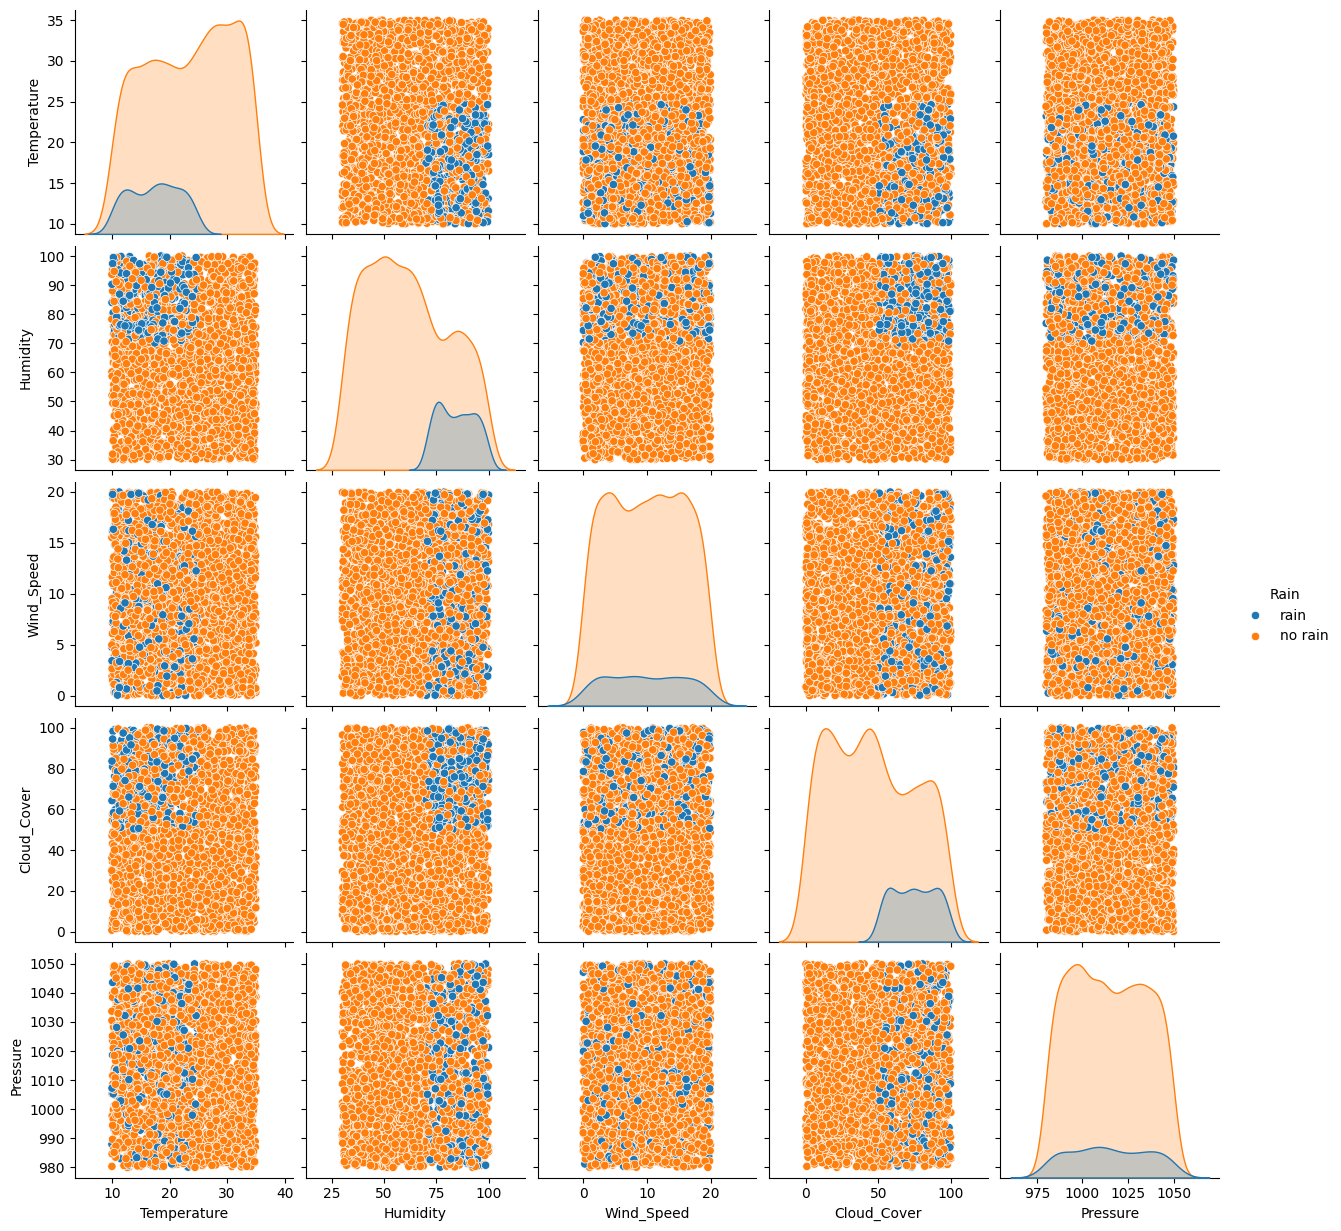

In [48]:
# Pairwise Relationship
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="Rain")
plt.show()

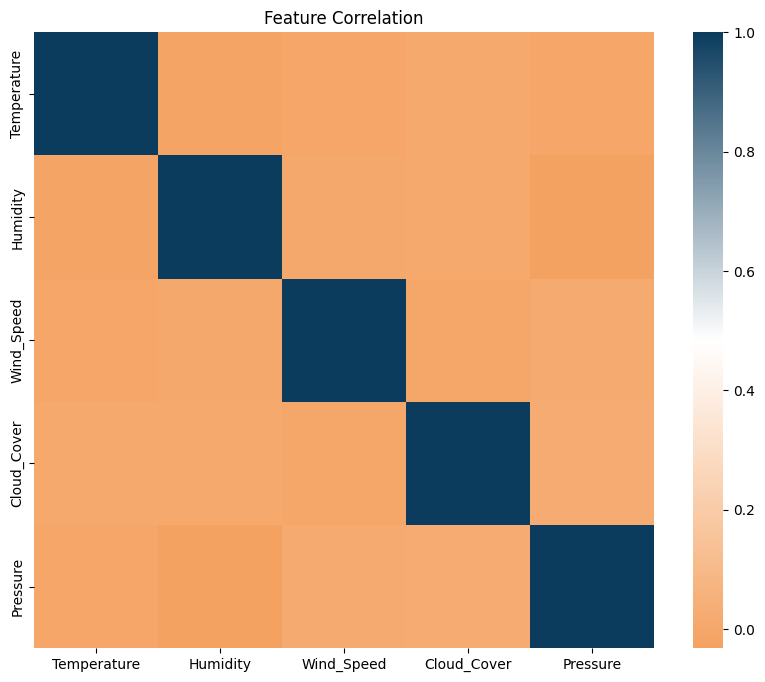

In [49]:
# Feature Correlation
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_diverging",
    [COLORS["no_rain"], "white", COLORS["rain"]]  # orange → white → deep blue
)

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap=custom_cmap, annot=False)

plt.title("Feature Correlation")
plt.show()

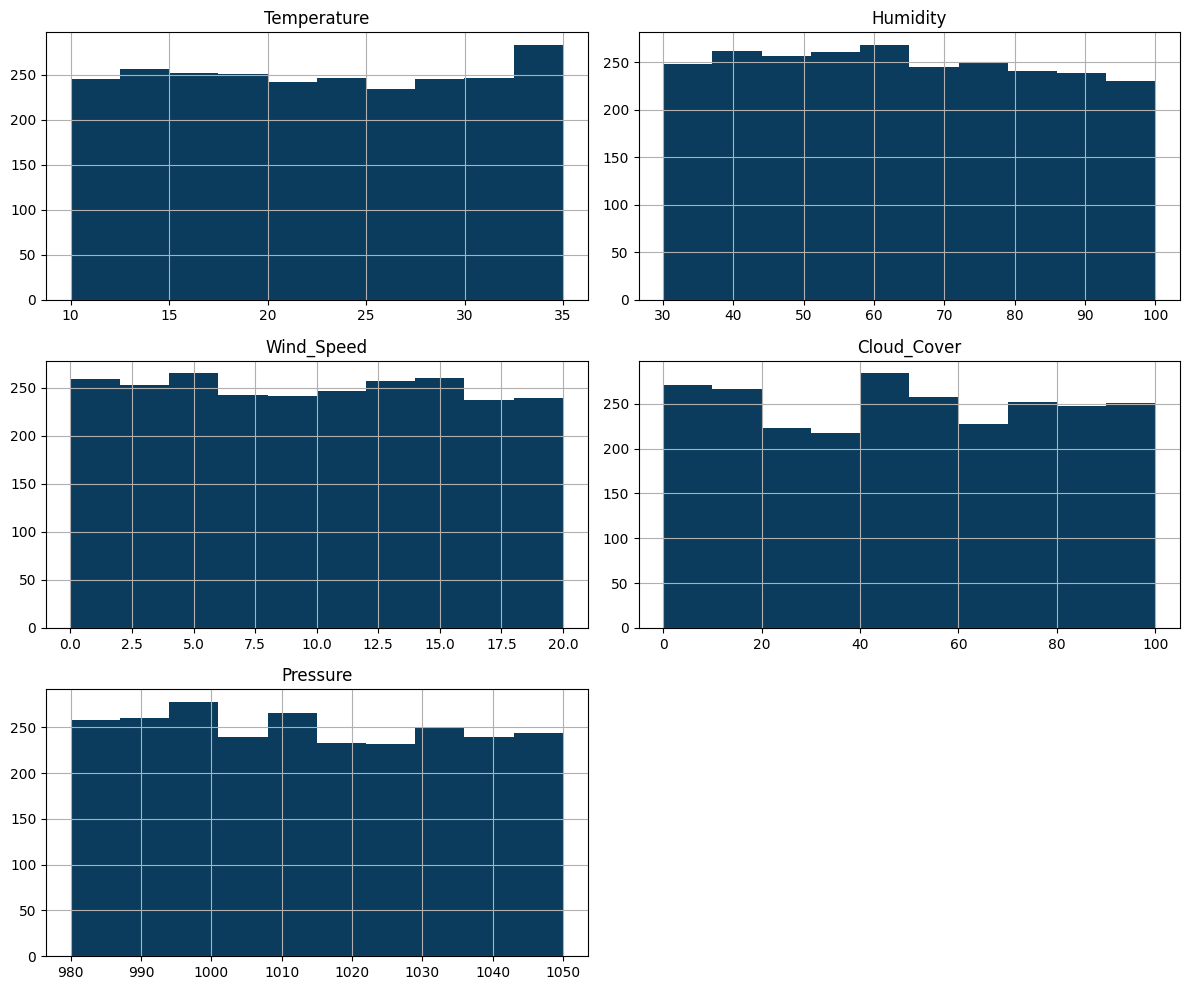

In [50]:
# Feature Distribution
deep_blue = COLORS["rain"]
df.hist(figsize=(12, 10), color=deep_blue)
plt.tight_layout()
plt.show()

- **Feature Distribution:** The numerical features influencing the outcome of rain are balanced.

In [51]:
# Handling duplicates
print("Number of duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates()
print("Number of duplicate rows after removal:", df.duplicated().sum())

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


In [52]:
# Handling missing data
# Fill numeric missing values with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [53]:
# Split into features and target
X = df.drop(columns=[target_column])
y = df[target_column]

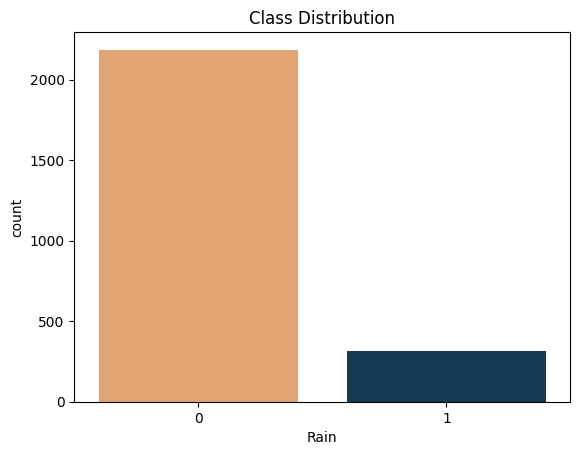

In [54]:
# Class Distribution
# Class Distribution
y_encoded = y.map({
    "no rain": 0,
    "rain": 1
})

palette = {
    1: COLORS["rain"],
    0: COLORS["no_rain"]
}

sns.countplot(x=y_encoded, hue=y_encoded, palette=palette, legend=False)

plt.title("Class Distribution")
plt.show()

- **Class Distribution:** There exists a considerable class imbalance, with a higher number of no rain instances compared to rain.

#### **Encoding, Scaling, and Train-Test Split**

- The target variable is encoded into numeric form if needed.
- Features are standardized using `StandardScaler` later in the model development pipeline to ensure consistent scaling across variables.
- The dataset is split into training and testing sets (80/20), with stratification applied when appropriate to preserve class distribution.
- Scaling is fitted on the training set and applied to both training and test data.

In [55]:
# Encode
y = y_encoded


In [56]:

from sklearn.model_selection import train_test_split

feature_names = X.columns

In [57]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## **2. Model Development**

The three baseline models were trained and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

This initial comparison helps establish how each model performs before optimization:

- **Logistic Regression** provides a simple and interpretable baseline.
- **Decision Tree** captures non-linear relationships in the dataset.
- **KNN** predicts based on similarity between weather observations.

In [58]:
# imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [59]:
# Model Initialization
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
}


In [60]:
# Evaluate function
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, average='weighted', zero_division=0),
        "recall": recall_score(y_test, preds, average='weighted', zero_division=0),
        "f1": f1_score(y_test, preds, average='weighted', zero_division=0),
        "roc_auc": roc_auc_score(y_test, probs)
    }

In [61]:
# Fit and Display evaluation (baseline)
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = evaluate(model, X_test, y_test)

baseline_df = pd.DataFrame(results).T
display(baseline_df)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.926,0.924573,0.926,0.925224,0.964912
Decision Tree,0.998,0.998031,0.998,0.998007,0.998856
KNN,0.964,0.963567,0.964,0.963751,0.982020


### Baseline Model Performance

The baseline results show strong initial performance across all models.

- **Decision Tree** performs best overall with near-perfect scores across all metrics.
- **KNN** shows strong performance but slightly lower ROC-AUC compared to the Decision Tree.
- **Logistic Regression** performs well but is the weakest among the three models.

Overall, even without tuning, the dataset appears to be highly predictable.

## **3. Hyperparameter Tuning**

To improve prediction accuracy, we use **GridSearchCV** with cross-validation to test multiple parameter combinations and identify the best-performing configuration for each model.

In [62]:
# @title
from sklearn.model_selection import GridSearchCV

In [63]:
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

log_grid = GridSearchCV(
    pipe_log,
    param_grid,
    cv=5,
    scoring="roc_auc"
)

In [64]:
pipe_tree = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_grid = GridSearchCV(
    pipe_tree,
    {
        "model__max_depth": [3,5,10,None],
        "model__min_samples_split": [2,5,10]
    },
    cv=5,
    scoring="roc_auc"
)

In [65]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_grid = GridSearchCV(
    pipe_knn,
    {
        "model__n_neighbors": list(range(3, 15, 2)),
        "model__weights": ["uniform", "distance"]
    },
    cv=5,
    scoring="roc_auc"
)

In [66]:
# @title
log_grid.fit(X_train, y_train)
tree_grid.fit(X_train, y_train)
knn_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsClassifier())]),
             param_grid={'model__n_neighbors': [3, 5, 7, 9, 11, 13],
                         'model__weights': ['uniform', 'distance']},
             scoring='roc_auc')

In [67]:
print("Best Parameters")
print("Best Logistic Regression:", log_grid.best_params_)
print("Best Decision Tree:", tree_grid.best_params_)
print("Best KNN:", knn_grid.best_params_)

Best Parameters
Best Logistic Regression: {'model__C': 1, 'model__solver': 'liblinear'}
Best Decision Tree: {'model__max_depth': 3, 'model__min_samples_split': 2}
Best KNN: {'model__n_neighbors': 13, 'model__weights': 'distance'}


In [68]:
tree = best_models["Decision Tree"]

estimator = tree.named_steps["model"]

print(estimator.get_depth())
print(estimator.get_n_leaves())

3
4


The best parameters found for each model are shown above.


## **4. Results and Evaluation**

In [69]:
# @title
best_models = {
    "Logistic Regression": log_grid.best_estimator_,
    "Decision Tree": tree_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_
}

tuned_results = {}

for name, model in best_models.items():
    tuned_results[name] = evaluate(model, X_test, y_test)

tuned_df = pd.DataFrame(tuned_results).T
display(tuned_df)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.926,0.924573,0.926,0.925224,0.964912
Decision Tree,0.998,0.998031,0.998,0.998007,0.998856
KNN,0.964,0.964000,0.964,0.964000,0.993426


In [70]:
# @title
import pandas as pd

before_df = pd.DataFrame(results).T
after_df = pd.DataFrame(tuned_results).T

print("BEFORE TUNING")
display(before_df)

print("\nAFTER TUNING")
display(after_df)

BEFORE TUNING


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.926,0.924573,0.926,0.925224,0.964912
Decision Tree,0.998,0.998031,0.998,0.998007,0.998856
KNN,0.964,0.963567,0.964,0.963751,0.982020



AFTER TUNING


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.926,0.924573,0.926,0.925224,0.964912
Decision Tree,0.998,0.998031,0.998,0.998007,0.998856
KNN,0.964,0.964000,0.964,0.964000,0.993426


### Before vs After Hyperparameter Tuning

There is minimal change between baseline and tuned results.

- **Logistic Regression** remains unchanged, indicating default parameters were already optimal.
- **Decision Tree** shows no improvement, suggesting it was already near optimal performance.
- **KNN** shows a small improvement in ROC-AUC after tuning, indicating better probability separation.

Overall, hyperparameter tuning had limited impact, likely because the models already perform very well on this dataset.

In [76]:
# @title
ranking = tuned_df.copy()
ranking["combined_score"] = 0.5*ranking["f1"] + 0.5*ranking["roc_auc"]
ranking["rank"] = ranking["combined_score"].rank(ascending=False)

display(ranking.sort_values("rank"))

,accuracy,precision,recall,f1,roc_auc,combined_score,rank
Decision Tree,0.998,0.998031,0.998,0.998007,0.998856,0.998431,1.0
KNN,0.964,0.964000,0.964,0.964000,0.993426,0.978713,2.0
Logistic Regression,0.926,0.924573,0.926,0.925224,0.964912,0.945068,3.0


### Final Model Ranking

The ranking combines F1-score and ROC-AUC to evaluate overall model quality.

- **Decision Tree** ranks first due to best accuracy and ROC-AUC. 🏆
- **KNN** ranks second with strong and stable performance after tuning.
- **Logistic Regression** ranks third but still performs well considering its simplicity.

The results suggest that tree-based models are best suited for this dataset, likely due to strong non-linear relationships in the features.

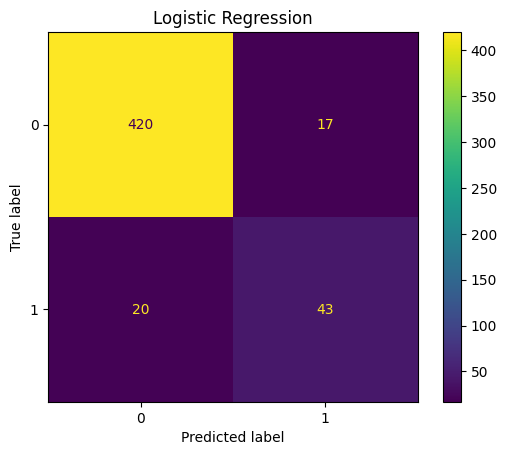

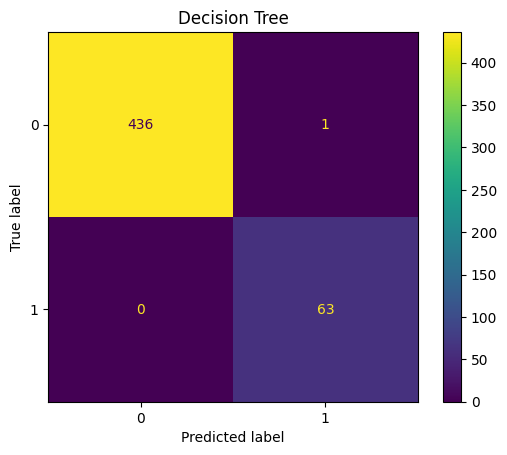

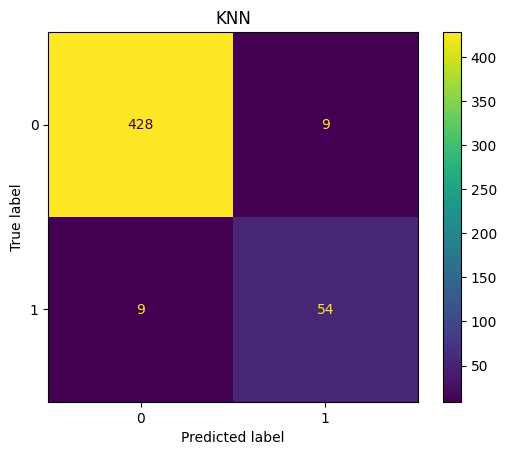

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in best_models.items():
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    ConfusionMatrixDisplay(cm).plot()
    plt.title(name)
    plt.show()

### Confusion Matrix Results Analysis
**Decision Tree** model is nearly perfect for this specific dataset.

- True Positives (63): Correctly identified all but one instance of Class 1.

- True Negatives (436): Correctly identified every single instance of Class 0.

- The Error: It only had one False Positive (it predicted 1 when the actual label was 0).

**K-Nearest Neighbors** model performed very well but was less precise than the Decision Tree.

- Symmetry: Interestingly, it missed exactly 9 instances of Class 0 and 9 instances of Class 1.

- Errors: It has a balanced spread of False Positives and False Negatives, totaling 18 errors.

**Logistic Regression** is still a good model , but it struggled the most with Class 1.
- False Negatives (20): Out of the 63 actual "Class 1" cases, it missed 20 of them (predicting 0 instead).

- False Positives (17): It incorrectly flagged 17 cases as "Class 1."

- Observation: This model seems to have a harder time distinguishing the boundary between the two classes compared to the other two algorithms.

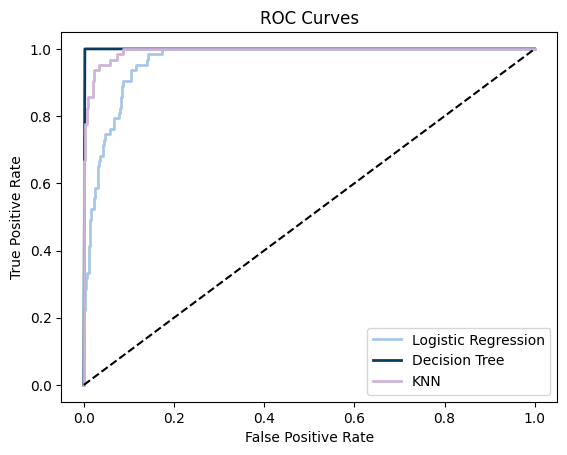

In [73]:
# @title

model_colors = {
    "Logistic Regression": COLORS["logistic"],
    "Decision Tree": COLORS["tree"],
    "KNN": COLORS["knn"]
}

from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in best_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(
        fpr, tpr,
        label=name,
        color=model_colors[name],
        linewidth=2
    )

plt.plot([0,1],[0,1],"--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curves")
plt.show()

### Receiver Operating Characteristic (ROC) Curve
In this graph, the **Decision Tree** is the top performer, nearly reaching a perfect Area Under the Curve (AUC) of $1.0$ instantly, which confirms its near-flawless classification. **KNN** follows closely with an excellent curve that stays high above the baseline, while **Logistic Regression** sits lowest of the three, showing that it requires a higher trade-off in False Positives to achieve the same True Positive Rate as the others. Overall, all three models significantly outperform the random-guess diagonal line.

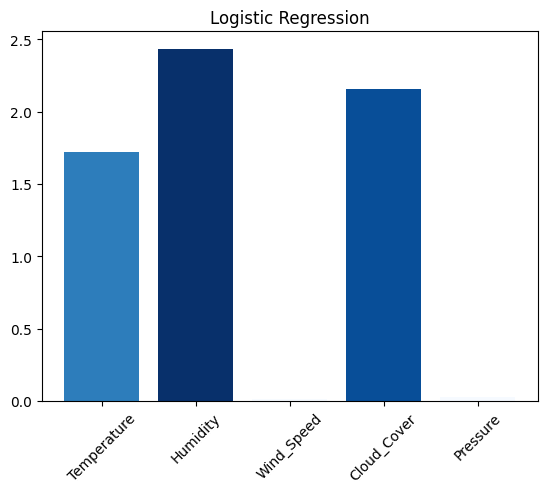

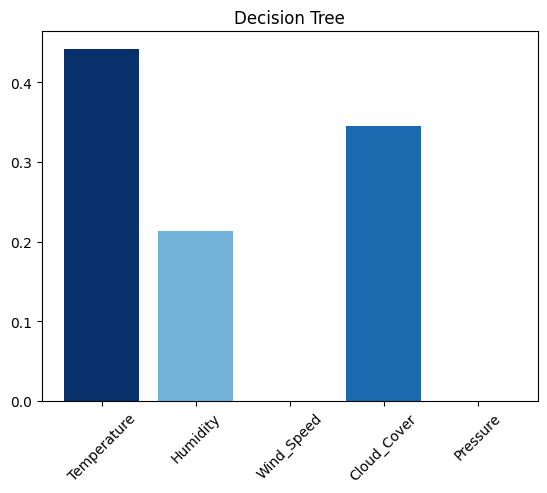

In [74]:
import matplotlib.cm as cm

for name, model in best_models.items():

    # extract underlying estimator from pipeline
    if hasattr(model, "named_steps"):
        estimator = model.named_steps["model"]
    else:
        estimator = model

    # tree-based models
    if hasattr(estimator, "feature_importances_"):
        importance = estimator.feature_importances_

    # logistic regression
    elif name == "Logistic Regression":
        importance = np.abs(estimator.coef_[0])

    else:
        continue

    # normalize importance → 0–1
    norm = (importance - importance.min()) / (importance.max() - importance.min() + 1e-8)

    colors = cm.Blues(norm)

    plt.figure()
    plt.bar(range(len(importance)), importance, color=colors)
    plt.xticks(range(len(importance)), feature_names, rotation=45)
    plt.title(name)
    plt.show()

### Feature Importance Analysis
The feature importance plots reveal a clear "disagreement" between our models, which might explain the performance gap seen earlier:

- **Decision Tree:** Heavily prioritizes Temperature. Its high accuracy suggests that Temperature likely has a "threshold" effect (a specific cutoff point) that is excellent for separating the classes.

- **Logistic Regression:** Relies mostly on Humidity and Cloud Cover. Because it looks for a straight-line relationship, it misses the complex Temperature patterns that the Tree model used to achieve higher accuracy.

\* *K-Nearest Neighbors does not provide intrinsic feature importance because it is a non-parametric, instance-based learning algorithm. Unlike tree-based models or linear models, it does not learn explicit feature weights or coefficients.*

*Therefore, feature importance analysis is not directly applicable and is omitted for this model to maintain consistency in interpretation across models.*

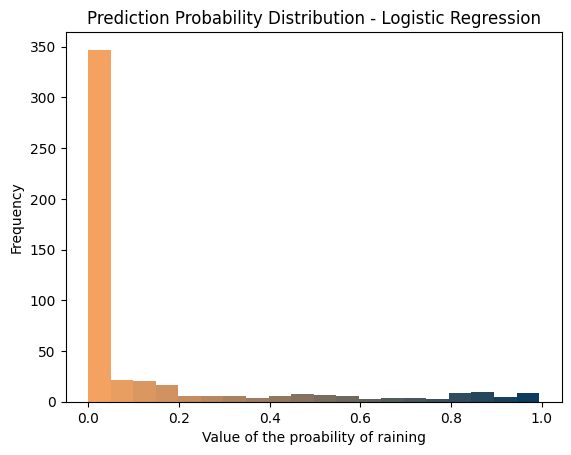

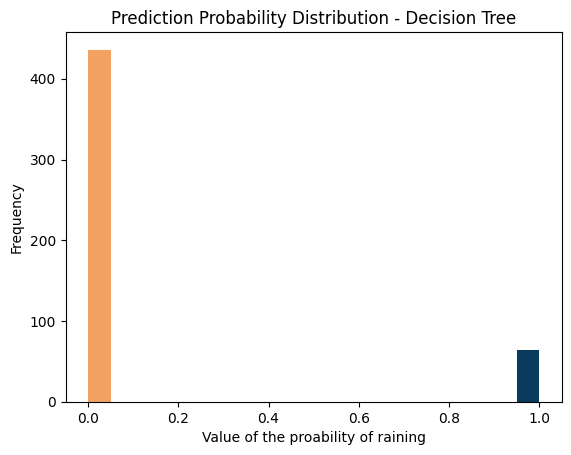

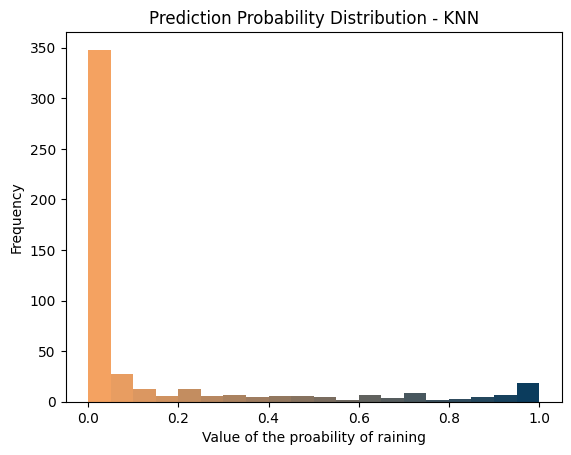

In [75]:
# @title
for name, model in best_models.items():
    probs = model.predict_proba(X_test)[:, 1]

    plt.figure()

    counts, bins, patches = plt.hist(probs, bins=20)

    # normalize bin centers
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    norm = (bin_centers - bin_centers.min()) / (bin_centers.max() - bin_centers.min())

    # custom gradient: orange → blue
    for c, p in zip(norm, patches):
        # interpolate between orange and blue
        r = (1-c)*244/255 + c*11/255
        g = (1-c)*162/255 + c*60/255
        b = (1-c)*97/255  + c*93/255
        p.set_facecolor((r, g, b))

    plt.title(f"Prediction Probability Distribution - {name}")
    plt.xlabel("Value of the proability of raining")
    plt.ylabel("Frequency")
    plt.show()

### Prediction Probability Distribution Analysis
**Logistic Regression:** This model shows the highest level of uncertainty, with a significant number of predictions falling in the 0.2 to 0.8 range. This "fuzzy" distribution explains its lower accuracy, as the model is often hesitant and struggles to clearly separate the two classes using a linear boundary.

**Decision Tree:** Displays extreme confidence, with nearly all predictions pushed to the far edges (0 or 1). While this resulted in near-perfect accuracy, the total lack of middle-ground probabilities is a major red flag for overfitting, suggesting the need for validation tests as explained earlier.

**KNN:** Setting a middle ground, KNN shows high confidence (clustering at the ends) but maintains a small "tail" of uncertainty. This indicates the model only feels 100% certain when a neighborhood of data points is in total agreement.